**References:**

1. Du, S. 2025. Findings from the Bank Marketing Dataset: Using Machine Learning to Forecast Term Deposit Subscriptions. In Proceedings of ICFTBA 2025 Symposium: Data-Driven Decision Making in Business and Economics, 62-69.

2. Bogireddy, S. R., and Murari, H. 2024. Machine Learning for Predictive Telemarketing: Boosting Campaign Effectiveness in Banking. In 2024 International Conference on Power, Energy, Control and Transmission Systems (ICPECTS). IEEE.

---

Both studies largely relied on XGBoost and Accuracy/AUC/F1 score for their evaluation which often fails to account for the asymmetric cost inherent in bank telemarketing where missing a subscriber (False Negative) is much more costly than an unsuccessful call (False Positive).

# Import Libraries and Read Dataset

In [1]:
# General Utilities & Data Handling
import pandas as pd
import numpy as np

# Visualisation & Styling
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

In [2]:
file_path = '../Data/bank_telemarketing.csv'
df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  int64  
 5   housing         41188 non-null  int64  
 6   loan            41188 non-null  int64  
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

# Actionable Insights (Visualisation)

In [3]:
# Global Style for Visualisation
plt.rcParams.update({
    "figure.facecolor":   "#FAFAF8",
    "axes.facecolor":     "#FAFAF8",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "axes.grid":          True,
    "grid.color":         "#E5E3DB",
    "grid.linewidth":     0.6,
    "axes.labelcolor":    "#5F5E5A",
    "axes.labelsize":     10,
    "xtick.color":        "#888780",
    "ytick.color":        "#888780",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "font.family":        "DejaVu Sans",
})

TEAL   = "#1D9E75"
BLUE   = "#378ADD"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
AMBER  = "#EF9F27"
GRAY   = "#888780"
LGRAY  = "#D3D1C7"
LBLUE  = "#77B1D4"
BG     = "#FAFAF8"
RED    = "#e74c3c"
GREEN  = "#2ecc71"

TEXT_MAIN = "#222222"
TEXT_SUB  = "#666666"
GRID_COL  = "#E6E6E6"
BAR_COLOR = "#D6DEE8"

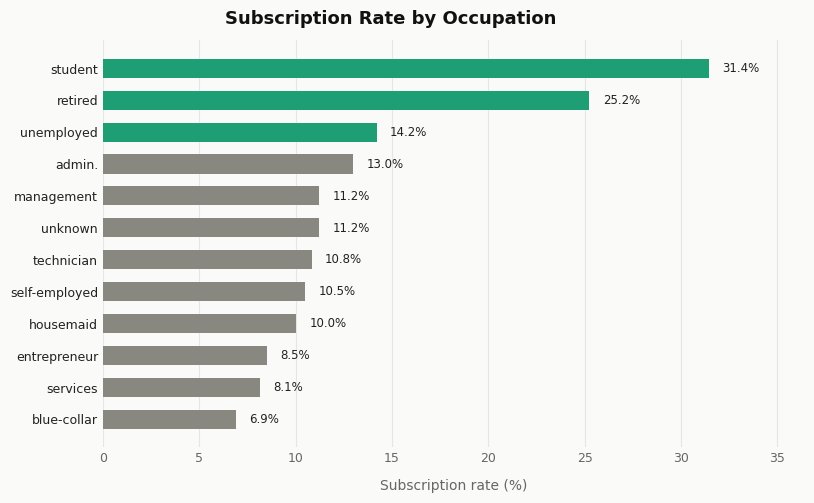

In [4]:
# Visulisation for Subscription Rate by Occupation

# Sort for better readability
job_rate = (df.groupby("job")["y"].mean() * 100).sort_values(ascending=True)

# Figure
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.subplots_adjust(top=0.82, bottom=0.08, left=0.18, right=0.96)

# Color logic
colors = [GRAY] * len(job_rate)
top_n = 3
for i in range(top_n):
    colors[-(i+1)] = TEAL  # highlight top 3 (since sorted ascending)

# Bars
spacing = 0.3
bars = ax.barh(
    job_rate.index,
    job_rate.values,
    color=colors,
    height=0.6,
    edgecolor="none"
)

# Value labels
for bar, val in zip(bars, job_rate.values):
    ax.text(
      val + 0.7,
      bar.get_y() + bar.get_height() / 2,
      f"{val:.1f}%",
      va="center",
      fontsize=8.5,
      color=TEXT_MAIN
)

# Axes styling
ax.set_xlabel("Subscription rate (%)", color=TEXT_SUB, labelpad=10)
ax.tick_params(axis='x', colors=TEXT_SUB, length=0)
ax.tick_params(axis='y', colors=TEXT_MAIN, length=0)
ax.set_xlim(0, job_rate.max() + 5)
ax.grid(axis="x", color=GRID_COL, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)

# Title
fig.text(
    0.5, 0.85,
    "Subscription Rate by Occupation",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#111111"
)

plt.show()

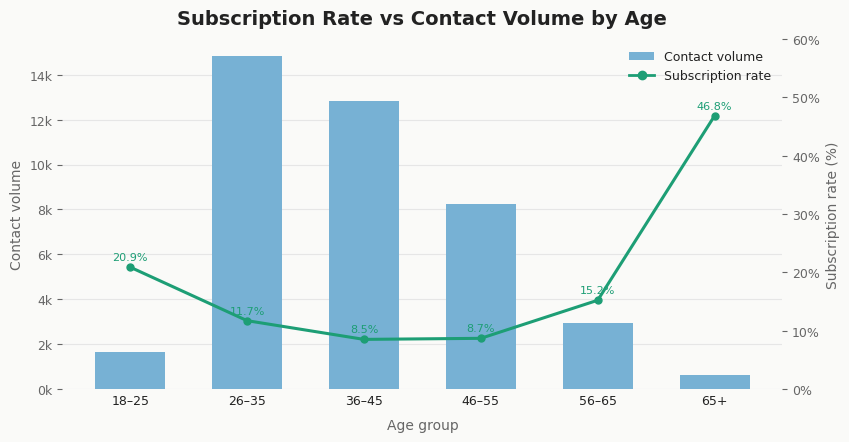

In [5]:
# Visulisation for Subscription Rate vs Contact Volume by Age

df["age_bin"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 98],
    labels=["18–25", "26–35", "36–45", "46–55", "56–65", "65+"]
)

age_stats = df.groupby("age_bin", observed=True)["y"].agg(
    rate=lambda x: x.mean() * 100,
    count="count"
)

# Figure
fig, ax1 = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(top=0.82, bottom=0.12, left=0.10, right=0.90)

x = np.arange(len(age_stats))

# Bars (volume)
bars = ax1.bar(
    x,
    age_stats["count"],
    color=LBLUE,
    width=0.6,
    edgecolor="none",
    zorder=2
)

# Left axis (volume)
ax1.set_xticks(x)
ax1.set_xticklabels(age_stats.index, color=TEXT_MAIN)
ax1.set_xlabel("Age group", color=TEXT_SUB, labelpad=8)
ax1.set_ylabel("Contact volume", color=TEXT_SUB)
ax1.tick_params(axis="y", colors=TEXT_SUB)
ax1.tick_params(axis="x", length=0)
ax1.grid(axis='x', visible=False)

# Grid
ax1.grid(axis="y", color=GRID_COL, linewidth=0.8)
ax1.set_axisbelow(True)

# Format y-axis as "k"
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k")
)

# Right axis (rate)
ax2 = ax1.twinx()

line = ax2.plot(
    x,
    age_stats["rate"],
    color=TEAL,
    marker="o",
    linewidth=2.2,
    markersize=5,
    zorder=3
)

ax2.set_ylabel("Subscription rate (%)", color=TEXT_SUB)
ax2.tick_params(axis="y", colors=TEXT_SUB)
ax2.set_ylim(0, 60)
ax2.grid(axis='y', visible=False)

# Format as percentage
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())


# Value labels on rate line
for i, v in enumerate(age_stats["rate"]):
    ax2.text(
        x[i],
        v + 1.2,
        f"{v:.1f}%",
        ha="center",
        fontsize=8,
        color=TEAL
    )

# Legend
legend_elements = [
    Patch(facecolor=LBLUE, label="Contact volume"),
    Line2D([0], [0], color=TEAL, marker="o", lw=2, label="Subscription rate")
]

leg = ax1.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False,
    fontsize=9
)

for text in leg.get_texts():
    text.set_color(TEXT_MAIN)

# Title
fig.text(
    0.5, 0.85,
    "Subscription Rate vs Contact Volume by Age",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color=TEXT_MAIN
)

plt.show()

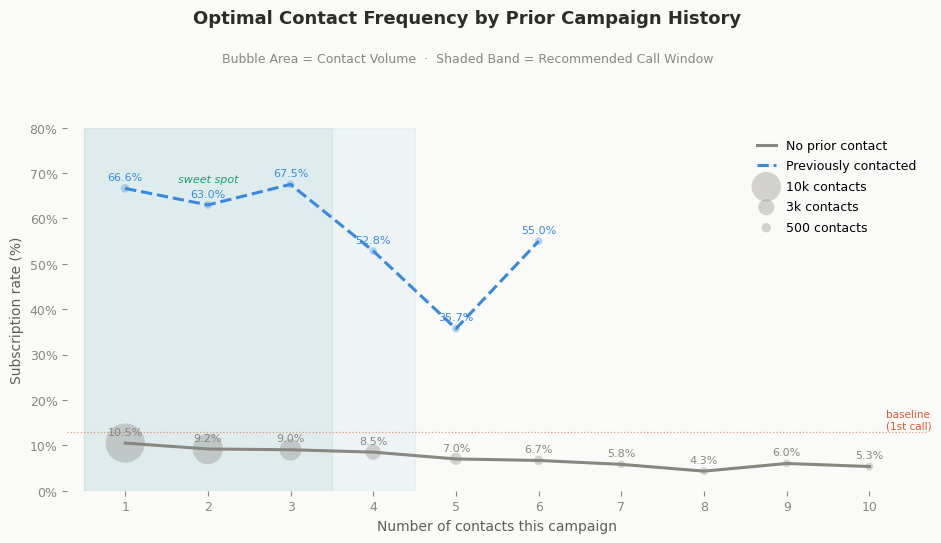

In [6]:
# Visualisation for Subscription Rate vs Contact Frequency
df["prev_contacted"] = (df["pdays"] != 999).astype(int)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.subplots_adjust(top=0.78, bottom=0.12, left=0.10, right=0.96)

max_camp = 10
camp_range = np.arange(1, max_camp + 1)

new_rates, prev_rates, new_n, prev_n = [], [], [], []
for c in camp_range:
    sub = df[df["campaign"] == c]
    n0 = sub[sub["prev_contacted"] == 0]
    n1 = sub[sub["prev_contacted"] == 1]
    new_rates.append(n0["y"].mean() * 100 if len(n0) > 10 else np.nan)
    prev_rates.append(n1["y"].mean() * 100 if len(n1) > 10 else np.nan)
    new_n.append(len(n0))
    prev_n.append(len(n1))

# Bubble sizes proportional to volume (new contacts only, for reference)
bubble_scale = 800
new_sizes  = [max(n / max(new_n) * bubble_scale, 30) for n in new_n]
prev_sizes = [max(n / max(new_n) * bubble_scale, 30) for n in prev_n]

# Shaded sweet-spot band (campaign 1–3 for new; 1–4 for prev)
ax.axvspan(0.5, 3.5, alpha=0.07, color=TEAL, zorder=0, label="_nolegend_")
ax.text(2.0, 68, "sweet spot", ha="center", fontsize=8,
        color=TEAL, style="italic")

ax.axvspan(0.5, 4.5, alpha=0.06, color=BLUE, zorder=0, label="_nolegend_")

# Lines
ax.plot(camp_range, new_rates,  color=GRAY, linewidth=2.2, zorder=3,
        marker="o", ms=0, label="No prior contact")
ax.plot(camp_range, prev_rates, color=BLUE, linewidth=2.2, zorder=3,
        linestyle="--", marker="o", ms=0, label="Previously contacted")

# Bubbles (volume encoded)
ax.scatter(camp_range, new_rates,  s=new_sizes,  color=GRAY,
           alpha=0.35, zorder=4, edgecolors="none")
ax.scatter(camp_range, prev_rates, s=prev_sizes, color=BLUE,
           alpha=0.35, zorder=4, edgecolors="none")

# Value labels
for x, y in zip(camp_range, new_rates):
    if not np.isnan(y):
        ax.text(x, y + 1.8, f"{y:.1f}%", ha="center", fontsize=8, color=GRAY)
for x, y in zip(camp_range, prev_rates):
    if not np.isnan(y):
        ax.text(x, y + 1.8, f"{y:.1f}%", ha="center", fontsize=8, color=BLUE)

# Threshold line
ax.axhline(13.0, color=CORAL, linewidth=0.9, linestyle=":", alpha=0.6)
ax.text(10.2, 13.2, "baseline\n(1st call)", fontsize=7.5, color=CORAL, va="bottom")

ax.set_xlabel("Number of contacts this campaign")
ax.set_ylabel("Subscription rate (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(camp_range)
ax.set_xlim(0.3, 10.7)
ax.set_ylim(0, 80)
ax.grid(axis="y"); ax.grid(axis="x", visible=False)

# Bubble legend (size guide)
for size_val, label in [(500, "10k contacts"), (150, "3k contacts"), (50, "500 contacts")]:
    ax.scatter([], [], s=size_val * 0.9, color=GRAY, alpha=0.35,
               edgecolors="none", label=label)

leg = ax.legend(frameon=False, fontsize=9, loc="upper right",
                handlelength=1.5, labelspacing=0.6)

fig.text(0.5, 0.97, "Optimal Contact Frequency by Prior Campaign History",
         ha="center", fontsize=13, fontweight="bold", color="#2C2C2A")
fig.text(0.5, 0.90,
         "Bubble Area = Contact Volume  ·  Shaded Band = Recommended Call Window",
         ha="center", fontsize=9, color="#888780")

plt.show()

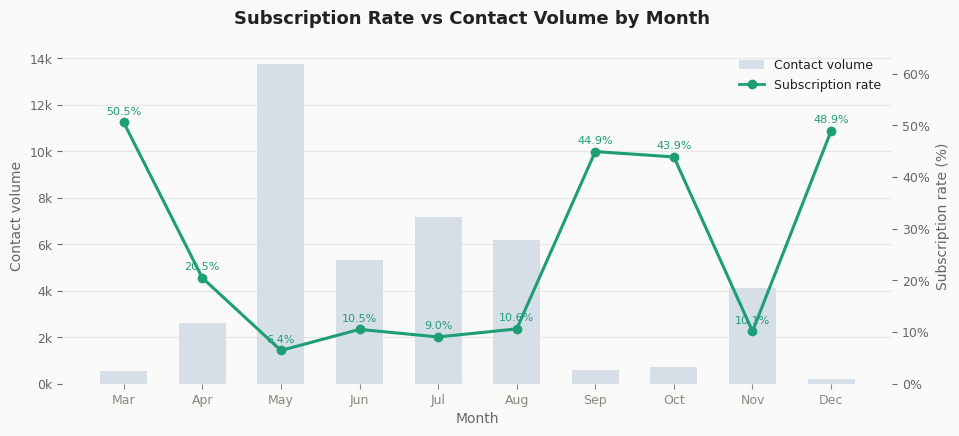

In [7]:
# Visulisation for Subscription Rate vs Contact Volume by Month
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

month_stats = (
    df.groupby("month")["y"]
      .agg(rate=lambda x: x.mean() * 100, count="count")
      .reindex(month_order)
      .reset_index()
      .rename(columns={"index": "month"})
)

x = np.arange(len(month_order))

fig, ax1 = plt.subplots(figsize=(10, 4.8))
fig.subplots_adjust(top=0.80, bottom=0.10, left=0.09, right=0.92)

# --- Bars (Contact Volume) ---
ax1.bar(
    x,
    month_stats["count"],
    color=BAR_COLOR,
    width=0.6,
    zorder=2
)

ax1.set_ylabel("Contact volume", color=TEXT_SUB)
ax1.tick_params(axis="y", colors=TEXT_SUB)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k")
)

# Subtle grid
ax1.grid(axis="y", color=GRID_COL, linewidth=0.8)
ax1.set_axisbelow(True)

# --- X-axis ---
ax1.set_xticks(x)
ax1.set_xticklabels([m.capitalize() for m in month_order])
ax1.set_xlabel("Month", color=TEXT_SUB)
ax1.grid(axis='x', visible=False)

# --- Line (Conversion Rate) ---
ax2 = ax1.twinx()

ax2.plot(
    x,
    month_stats["rate"],
    color=TEAL,
    marker="o",
    ms=6,
    linewidth=2.2,
    zorder=3
)

ax2.set_ylabel("Subscription rate (%)", color=TEXT_SUB)
ax2.tick_params(axis="y", colors=TEXT_SUB)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_ylim(0, 65)
ax2.grid(axis='y', visible=False)

# Clean right spine
ax2.spines["right"].set_visible(False)

# --- Value labels ---
for i, v in enumerate(month_stats["rate"]):
    if np.isfinite(v):
        ax2.text(
            x[i],
            v + 1.5,
            f"{v:.1f}%",
            ha="center",
            fontsize=8,
            color=TEAL
        )

# --- Legend ---
legend_elements = [
    Patch(facecolor=BAR_COLOR, label="Contact volume"),
    Line2D([0], [0], color=TEAL, marker="o", lw=2, label="Subscription rate")
]

leg = ax1.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False,
    fontsize=9
)

for text in leg.get_texts():
    text.set_color(TEXT_MAIN)

# --- Title ---
fig.text(
    0.5, 0.85,
    "Subscription Rate vs Contact Volume by Month",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color=TEXT_MAIN
)

plt.show()

# Data Preprocessing

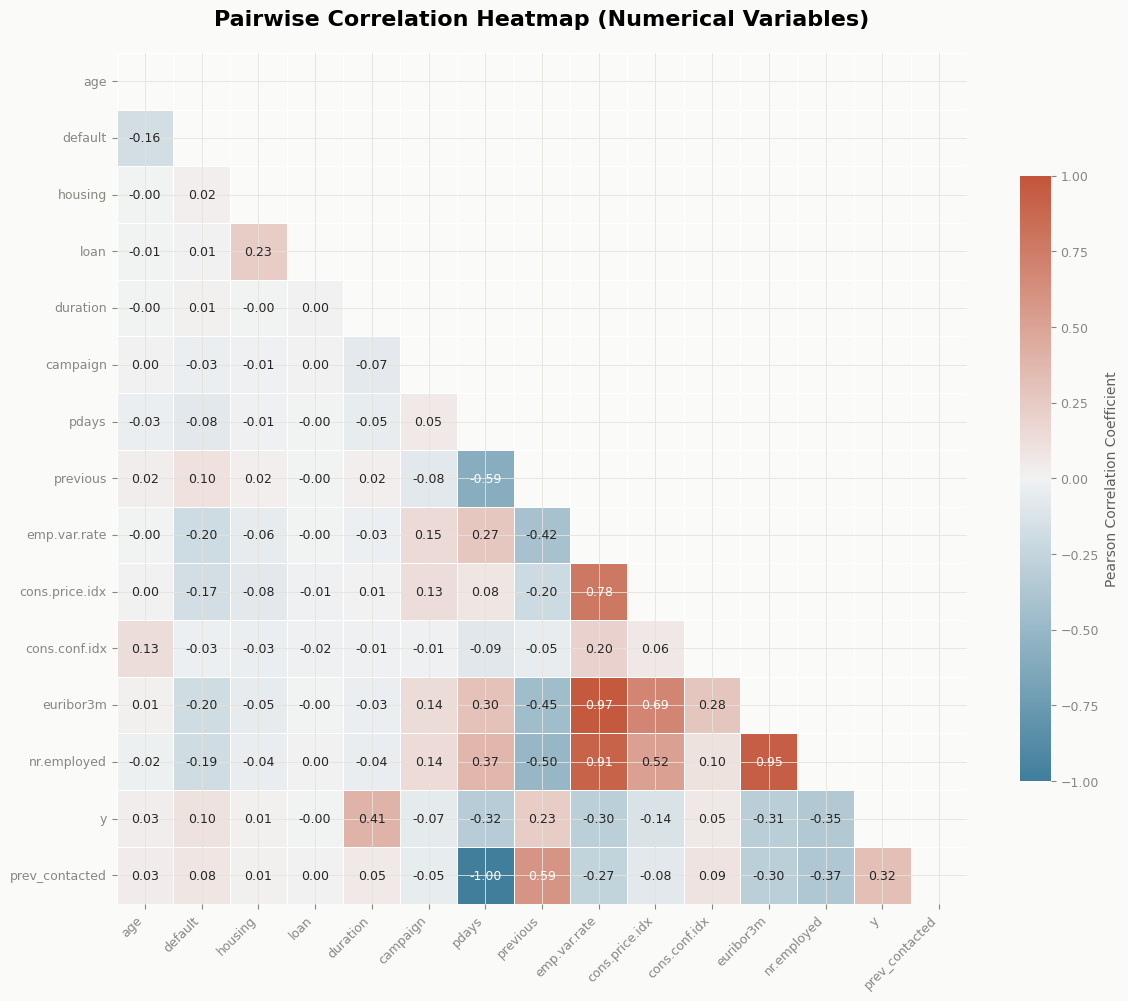

In [8]:
# Compute the correlation matrix
# We focus only on numerical features
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Create a Mask for the Upper Triangle
# This prevents visual redundancy and makes it much cleaner for reports
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualization Setup
plt.figure(figsize=(12, 10))

# Custom Diverging Color Palette (Cool to Warm)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7, "label": "Pearson Correlation Coefficient"},
    annot=True,     # Set to False if you have too many variables
    fmt=".2f",      # Rounds numbers to 2 decimal places
    annot_kws={"size": 9}
)

# Professional Styling
plt.title('Pairwise Correlation Heatmap (Numerical Variables)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [9]:
col_from_visual = ['age_bin', 'prev_contacted']
df.drop(columns=col_from_visual, inplace=True)
print(df.info())

# Add a new column 'contacted' to indicate whether the client has been contacted before
df['contacted'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)

# Drop 'default' column as there is only 3 positive cases, which is not enough for modeling
df.drop(columns=['default'], inplace=True)

# Analyze the distribution of the target variable 'y'
df['y'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  int64  
 5   housing         41188 non-null  int64  
 6   loan            41188 non-null  int64  
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

In [10]:
features_with_unknown = ['job', 'marital', 'housing', 'loan', 'education']
# Calculate percentages
for col in features_with_unknown:
    if df[col].dtype == 'object':
        # Check for string 'unknown'
        count = (df[col] == 'unknown').sum()
    else:
        # Check for numeric code -1
        count = (df[col] == -1).sum()
    percentage = (count / len(df)) * 100
    print(f"{col:10} | Percentage: {percentage:.2f}%")

job        | Percentage: 0.80%
marital    | Percentage: 0.19%
housing    | Percentage: 2.40%
loan       | Percentage: 2.40%
education  | Percentage: 4.20%


In [11]:
# Impute missing values in 'job', 'marital', 'housing', loan' columns with the mode
# as less than 5% of the data is missing and these are categorical features
# Reduce likelihood of 'unknown' values weakening predictive signals
df.fillna({'job': df['job'].mode()[0],
           'marital': df['marital'].mode()[0],
           'housing': df['housing'].mode()[0],
           'loan': df['loan'].mode()[0]},
           inplace=True)

In [12]:
# Encoding categorical varaibles
# Binary encoding for 'contact' column
df['contact'] = df['contact'].map({'telephone': 0, 'cellular': 1})

# Ordinal encoding for 'education' column
# Education has a clear real-world hierarchy (more schooling = higher level)
# Treat 'unknown' as a distinct category (4.2%) rather than missing, as it may represent a specific behavioural group (e.g. non-disclosure)
edu_order = {
    'illiterate':          1,    # merged into basic.4y tier (n=18, unreliable alone)
    'basic.4y':            1,
    'basic.6y':            2,
    'basic.9y':            3,
    'unknown':             4,  # neutral midpoint — distinct behavioural group
    'high.school':         5,
    'professional.course': 6,
    'university.degree':   7
}
df['education'] = df['education'].map(edu_order)

# One-hot encoding for 'job', 'marital', 'housing', 'loan' columns
df = pd.get_dummies(df,
                    columns=['job', 'marital', 'housing', 'loan', 'month', 'day_of_week'],
                    drop_first=True,
                    dtype=int)

In [13]:
# Drop columns before scaling to avoid unnecessary processing

# Drop 'pdays' as it is accounted for in 'contacted'.
# Drop 'duration' as including it introduces data leakage.
# Drop 'emp.var.rate' it has a strong correlation with 'euribor3m' and 'nr.employed',
# and is redundant when 'euribor3m' and 'nr.employed' which are more interpretable are included.

cols_to_drop = ['pdays', 'duration', 'emp.var.rate']
df_clean = df.drop(columns=cols_to_drop)

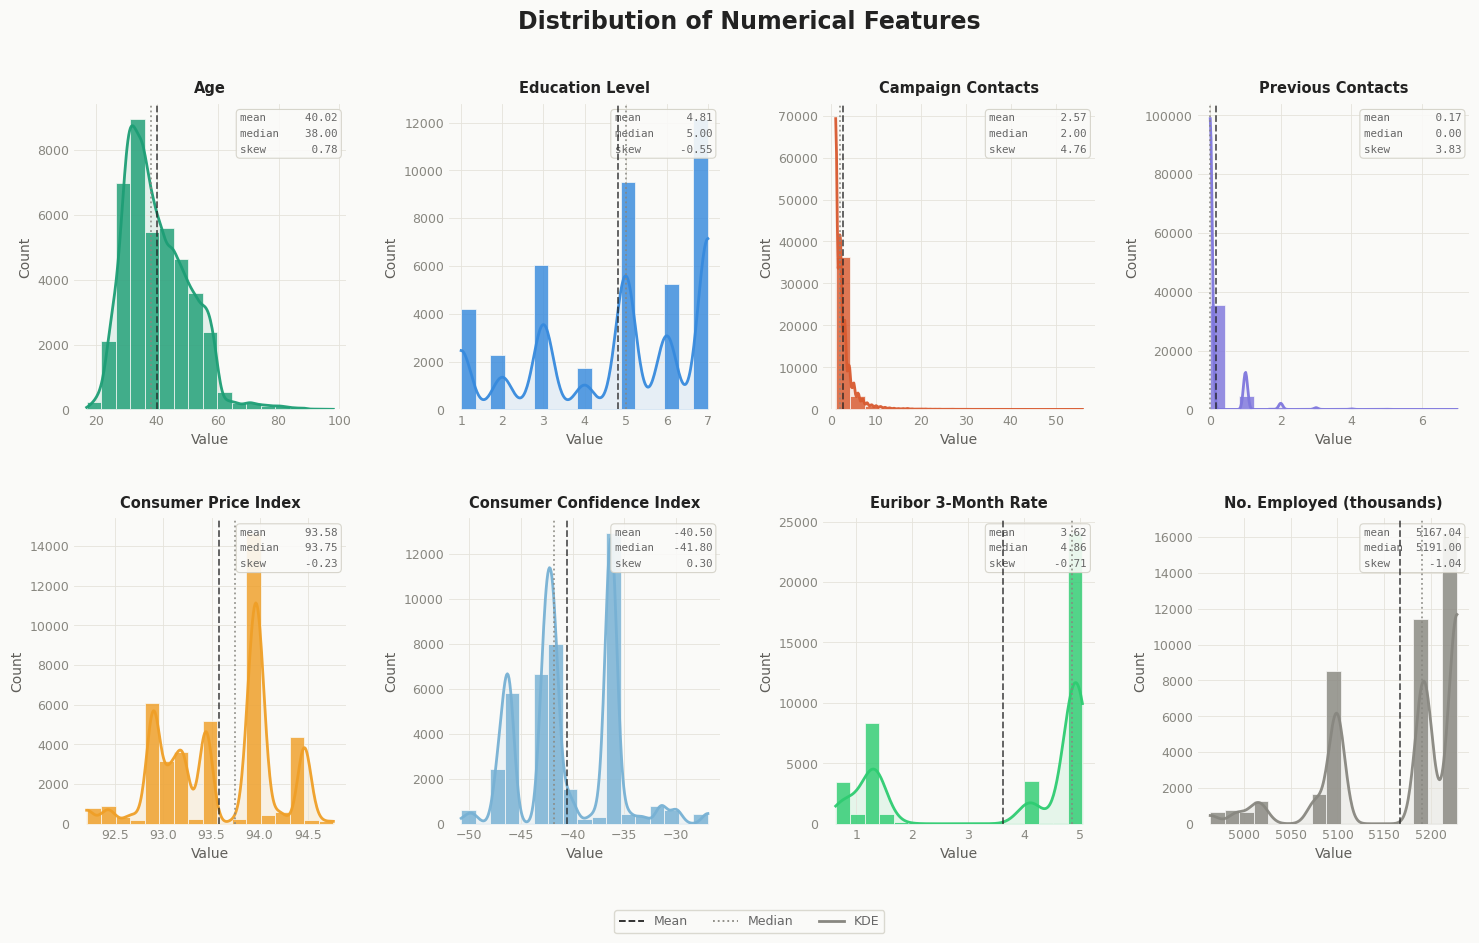

In [14]:
# Distribution of different numerical features
features = ['age', 'education', 'campaign', 'previous',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

colors = [TEAL, BLUE, CORAL, PURPLE, AMBER, LBLUE, GREEN, GRAY]

pretty_labels = {
    'age':            'Age',
    'education':      'Education Level',
    'campaign':       'Campaign Contacts',
    'previous':       'Previous Contacts',
    'cons.price.idx': 'Consumer Price Index',
    'cons.conf.idx':  'Consumer Confidence Index',
    'euribor3m':      'Euribor 3-Month Rate',
    'nr.employed':    'No. Employed (thousands)',
}

# Figure layout
fig = plt.figure(figsize=(18, 11), facecolor=BG)

fig.text(0.5, 0.85, 'Distribution of Numerical Features', fontsize=17, fontweight='bold',
         color=TEXT_MAIN, ha='center', va='top')

outer = gridspec.GridSpec(
    3, 1, figure=fig,
    height_ratios=[0.06, 1, 1],
    hspace=0.52
)

row1_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[1], wspace=0.38)
row2_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[2], wspace=0.38)


# Helper: draw one histogram panel
def draw_panel(ax, data, label, color):
    n      = len(data)
    skew   = data.skew()
    mean_v = data.mean()
    med_v  = data.median()

    n_bins = min(int(np.ceil(np.log2(n) + 1)), 50)

    counts, edges, patches = ax.hist(
        data, bins=n_bins,
        color=color, alpha=0.82,
        edgecolor=BG, linewidth=0.6,
        zorder=2
    )

    kde_x = np.linspace(data.min(), data.max(), 300)
    kde   = stats.gaussian_kde(data, bw_method='scott')
    kde_y = kde(kde_x)
    bin_width = edges[1] - edges[0]
    scale     = n * bin_width
    ax.plot(kde_x, kde_y * scale, color=color, linewidth=2.0, alpha=0.95, zorder=3)
    ax.fill_between(kde_x, kde_y * scale, alpha=0.10, color=color, zorder=1)

    ax.axvline(mean_v, color=TEXT_MAIN, linewidth=1.3, linestyle='--', alpha=0.75, zorder=4)
    ax.axvline(med_v,  color=GRAY,      linewidth=1.3, linestyle=':',  alpha=0.85, zorder=4)

    stats_txt = (
        f"mean   {mean_v:>8.2f}\n"
        f"median {med_v:>8.2f}\n"
        f"skew   {skew:>8.2f}"
    )
    ax.text(0.97, 0.97, stats_txt,
            transform=ax.transAxes,
            fontsize=7.8, color=TEXT_SUB,
            va='top', ha='right',
            linespacing=1.7,
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.35', facecolor=BG,
                      edgecolor=LGRAY, linewidth=0.8, alpha=0.9))

    ax.set_title(label, fontsize=10.5, fontweight='semibold', color=TEXT_MAIN, pad=8)
    ax.set_xlabel('Value', labelpad=4)
    ax.set_ylabel('Count', labelpad=4)
    ax.yaxis.set_tick_params(length=0)
    ax.xaxis.set_tick_params(length=0)


# Draw all 8 panels (4 per row)
row_specs = [row1_gs, row2_gs]
for i, (feat, color) in enumerate(zip(features, colors)):
    gs   = row_specs[i // 4]
    ax   = fig.add_subplot(gs[i % 4])
    draw_panel(ax, df[feat], pretty_labels[feat], color)

# Shared legend
legend_elements = [
    Line2D([0], [0], color=TEXT_MAIN, linewidth=1.3, linestyle='--', label='Mean'),
    Line2D([0], [0], color=GRAY,      linewidth=1.3, linestyle=':',  label='Median'),
    Line2D([0], [0], color=GRAY,      linewidth=2.0, linestyle='-',  label='KDE'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=9, frameon=True,
           facecolor=BG, edgecolor=LGRAY,
           labelcolor=TEXT_SUB,
           bbox_to_anchor=(0.5, 0.005),
           columnspacing=2.0, handlelength=2.0)

plt.show()